# 🔍 Bloom Filter — Netflix EDA

**Detección de Bots y Solicitudes Duplicadas**  
Curso: Estructuras de Datos y Algoritmos | UTEC

---

## ¿Qué es un Bloom Filter?

Un **Bloom Filter** es una estructura de datos probabilística para verificar si un elemento pertenece a un conjunto. Sus propiedades clave:

- ✅ **Sin falsos negativos**: Si el filtro dice que un elemento NO está, definitivamente no está.
- ⚠️ **Posibles falsos positivos**: Un elemento puede aparecer como si estuviera cuando en realidad no está.
- 💾 **Ultra eficiente en memoria**: Usa solo bits, no almacena los elementos.

### Fórmulas Óptimas

Dado n (capacidad) y p (tasa de falsos positivos deseada):
- **Bits necesarios**: `m = -n × ln(p) / (ln(2))²`
- **Funciones hash**: `k = (m/n) × ln(2)`

### Uso en Netflix

1. **Detección de bots**: Si una IP hace 1000 solicitudes/segundo, probablemente es un bot
2. **Solicitudes duplicadas**: Evitar procesar el mismo request dos veces
3. **Caché distribuido**: Verificar si un video está en caché antes de buscarlo

In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/Guido-Silva/netflix-streaming-eda.git
    %cd netflix-streaming-eda
    PROJECT_ROOT = Path.cwd().resolve()
else:
    cwd = Path.cwd().resolve()
    PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

INFORME_DIR = PROJECT_ROOT / "informe"
INFORME_DIR.mkdir(parents=True, exist_ok=True)

print(f"Entorno configurado | PROJECT_ROOT={PROJECT_ROOT}")


Entorno configurado | PROJECT_ROOT=C:\Users\jsilvac\Documents\UTEC Maestria\2do ciclo\Estructuras de Datos y Algoritmos\Proyecto Final\netflix-streaming-eda


In [2]:
from src.bloom_filter import BloomFilter
print('✅ Módulo Bloom Filter importado')

✅ Módulo Bloom Filter importado


In [3]:
from src.bloom_filter import demo
demo()

   DEMO: Bloom Filter - Detección de Bots Netflix

📋 Configuración del Bloom Filter:
  capacidad: 10000
  error_rate_objetivo: 0.01
  tamaño_bits: 95851
  tamaño_bytes: 11982
  num_hashes: 7
  elementos_insertados: 0
  tasa_fp_actual: 0.0
  memoria_KB: 11.7

✅ Registrando 1000 IPs/usuarios legítimos:
  Falsos negativos (NUNCA debería haber): 0
  Tasa FP actual: 0.0000%

🤖 Detectando posibles bots (1000 IPs no registradas):
  Falsos positivos detectados: 0/1000
  Tasa FP real: 0.0000% (objetivo: 1.0000%)

🔍 Consultas individuales:
  ¿'user_0_ip_192.168.0.0' es legítimo? True
  ¿'bot_999_ip_10.0.3.231' es legítimo? False


In [4]:
# Experimento: Tasa de falsos positivos vs capacidad insertada
import random
import numpy as np

print('📊 Experimento: Tasa de Falsos Positivos vs Llenado del Filtro')
print('=' * 60)

CAPACIDAD = 10000
bf = BloomFilter(capacity=CAPACIDAD, error_rate=0.01)

print(f'Configuración: m={bf.size} bits, k={bf.num_hashes} hashes, memoria={bf.size/8/1024:.2f} KB')
print()

elementos_insertados = []
tasas_fp = []
tasas_fp_teoricas = []

N_TEST = 1000  # Elementos de prueba

import math

for n_insert in range(0, CAPACIDAD + 1, 500):
    if n_insert > 0:
        # Insertar nuevos elementos
        for i in range(n_insert - len(elementos_insertados)):
            bf.add(f'legit_user_{len(elementos_insertados) + i}')
            elementos_insertados.append(f'legit_user_{len(elementos_insertados) + i}')
    
    # Medir tasa de falsos positivos
    fps = sum(1 for i in range(N_TEST) if bf.contains(f'nuevo_bot_{i + 100000}'))
    tasa_fp = fps / N_TEST
    
    # Calcular tasa teórica
    n = len(elementos_insertados)
    if n > 0:
        tasa_teorica = (1 - math.exp(-bf.num_hashes * n / bf.size)) ** bf.num_hashes
    else:
        tasa_teorica = 0.0
    
    tasas_fp.append(tasa_fp * 100)
    tasas_fp_teoricas.append(tasa_teorica * 100)
    
    if n_insert % 2000 == 0:
        print(f'  n={n_insert:>6}: FP real={tasa_fp:.4%} | FP teórico={tasa_teorica:.4%}')

print(f'\n  Capacidad objetivo del filtro: {CAPACIDAD}')
print(f'  Error rate objetivo: 1.00%')

📊 Experimento: Tasa de Falsos Positivos vs Llenado del Filtro
Configuración: m=95851 bits, k=7 hashes, memoria=11.70 KB

  n=     0: FP real=0.0000% | FP teórico=0.0000%
  n=  2000: FP real=0.0000% | FP teórico=0.0001%
  n=  4000: FP real=0.0000% | FP teórico=0.0067%
  n=  6000: FP real=0.0000% | FP teórico=0.0708%
  n=  8000: FP real=0.0000% | FP teórico=0.3320%
  n= 10000: FP real=0.0000% | FP teórico=1.0039%

  Capacidad objetivo del filtro: 10000
  Error rate objetivo: 1.00%


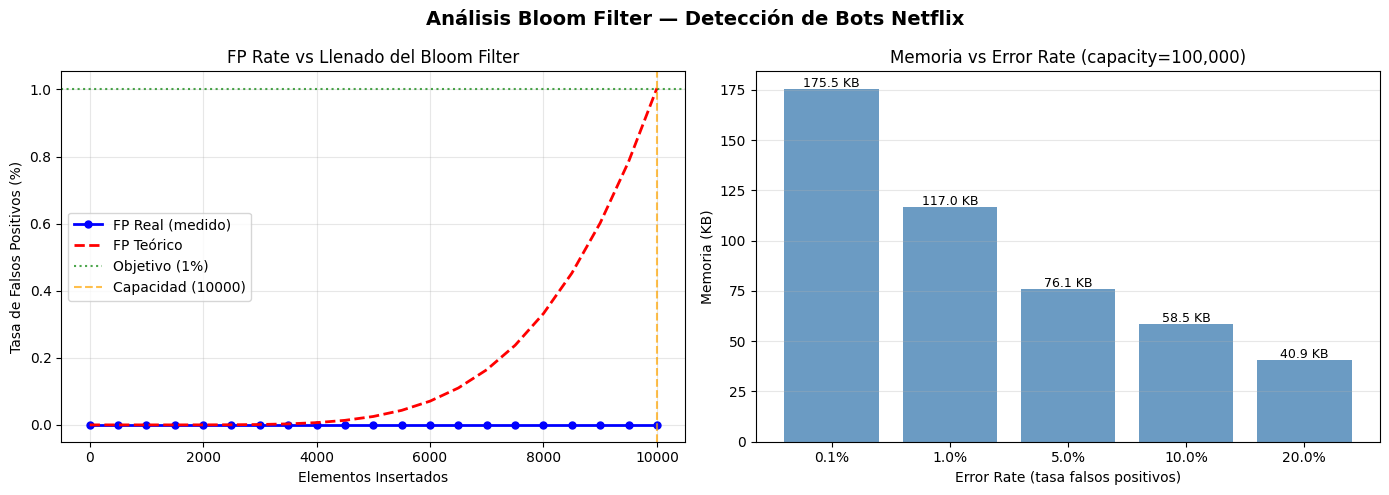

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_values = list(range(0, CAPACIDAD + 1, 500))

# Grafico 1: Tasa FP vs elementos insertados
axes[0].plot(x_values, tasas_fp, 'bo-', label='FP Real (medido)', linewidth=2, markersize=5)
axes[0].plot(x_values, tasas_fp_teoricas, 'r--', label='FP Teórico', linewidth=2)
axes[0].axhline(y=1.0, color='green', linestyle=':', alpha=0.7, label='Objetivo (1%)')
axes[0].axvline(x=CAPACIDAD, color='orange', linestyle='--', alpha=0.7, label=f'Capacidad ({CAPACIDAD})')
axes[0].set_xlabel('Elementos Insertados')
axes[0].set_ylabel('Tasa de Falsos Positivos (%)')
axes[0].set_title('FP Rate vs Llenado del Bloom Filter')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Grafico 2: Comparativa de memoria con diferentes error rates
error_rates = [0.001, 0.01, 0.05, 0.1, 0.2]
memorias_kb = []
for er in error_rates:
    bf_temp = BloomFilter(capacity=100000, error_rate=er)
    memorias_kb.append(bf_temp.size / 8 / 1024)

axes[1].bar([f'{er:.1%}' for er in error_rates], memorias_kb, color='steelblue', alpha=0.8)
axes[1].set_xlabel('Error Rate (tasa falsos positivos)')
axes[1].set_ylabel('Memoria (KB)')
axes[1].set_title('Memoria vs Error Rate (capacity=100,000)')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(memorias_kb):
    axes[1].text(i, v + 1, f'{v:.1f} KB', ha='center', fontsize=9)

plt.suptitle('Análisis Bloom Filter — Detección de Bots Netflix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(INFORME_DIR / 'bloom_fp_rate.png', dpi=100, bbox_inches='tight')
plt.show()

## 📊 Análisis de Complejidad

| Operación | Complejidad Temporal | Complejidad Espacial |
|-----------|---------------------|---------------------|
| `add(item)` | **O(k)** | O(1) adicional |
| `contains(item)` | **O(k)** | O(1) adicional |
| Espacio total | — | **O(m bits)** = O(-n ln(p) / ln(2)²) |

donde `k` = número de funciones hash (típicamente 5-10).

### Trade-off Memoria vs Precisión

| Error Rate | Memoria (100K elem) | Hashes (k) |
|-----------|---------------------|------------|
| 0.1% | ~180 KB | 10 |
| 1% | ~120 KB | 7 |
| 5% | ~78 KB | 5 |
| 10% | ~60 KB | 4 |

### Aplicación en Netflix

Netflix maneja ~500 millones de usuarios activos. Almacenar sus tokens de sesión con 1% error rate:
- HashSet exacto: ~500M × 20 bytes = **~10 GB**
- Bloom Filter (1% FP): ~500M × 1.2 bytes = **~600 MB** (17x menos memoria)